Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


pm shape: (200, 200)
pm shape: (200, 200)
pm shape: (200, 200)
pm shape: (200, 200)
pm shape: (200, 200)
pm shape: (200, 200)
pm shape: (200, 200)
pm shape: (200, 200)


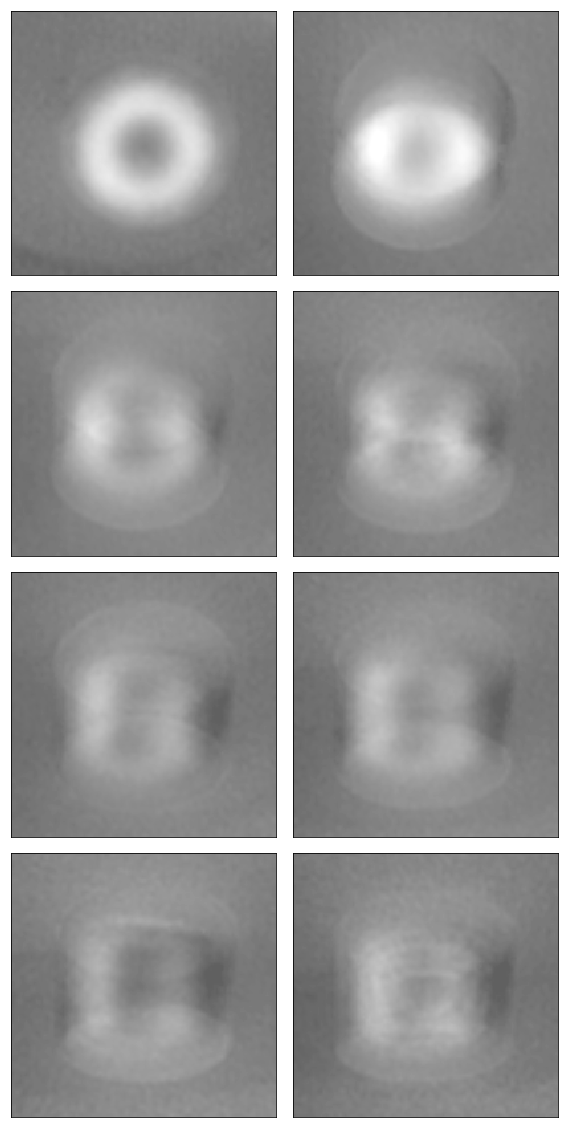

In [1]:
import sys
sys.path.extend(['/home/zhaoy/packages/Pyramid']) 
print('Python %s on %s' % (sys.version, sys.platform))

import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import hyperspy.api as hs
import pyramid as pr
from scipy.ndimage import gaussian_filter 

def remap_data(data, old_min, old_max, target_min=-0.5, target_max=0.5):
    data_clipped = np.clip(data, old_min, old_max)
    data_mapped = (data_clipped - old_min) / (old_max - old_min) * (target_max - target_min) + target_min
    return data_mapped

angles = [0,28,44,50,54,58,61,65]
fig1 = plt.figure(figsize=(8,16))
ax1 = {}
#magdata = hs.load('/home/zhaoy/studio/target-skyrmion/dataset/dm3_refin/mag_s_t_stack.dm3')
magdata = hs.load('./mag_s_t_stack.dm3')
phasemaps = []
for i, angle in enumerate(angles):
    tilt = angle
    pm = magdata.inav[i].data
    print("pm shape: {}".format(pm.shape))
    current_vmin = np.percentile(pm, 0)
    current_vmax = np.percentile(pm, 100)
    #pm_normalized = remap_data(pm, current_vmin, current_vmax)
    phasemaps.append(pr.PhaseMap(a=1, phase=pm))#_normalized))

    ax1[i+1] = fig1.add_subplot(4, 2, i+1, aspect='equal')
    ax1[i+1].get_xaxis().set_visible(False)
    ax1[i+1].get_yaxis().set_visible(False)
    phasemaps[i].flip('u').flip('v').plot_phase(axis=ax1[i+1],scalebar=False,cbar=False,cmap='gray',vmin=-0.5,vmax=2.0)
    plt.tight_layout(h_pad=0.4)

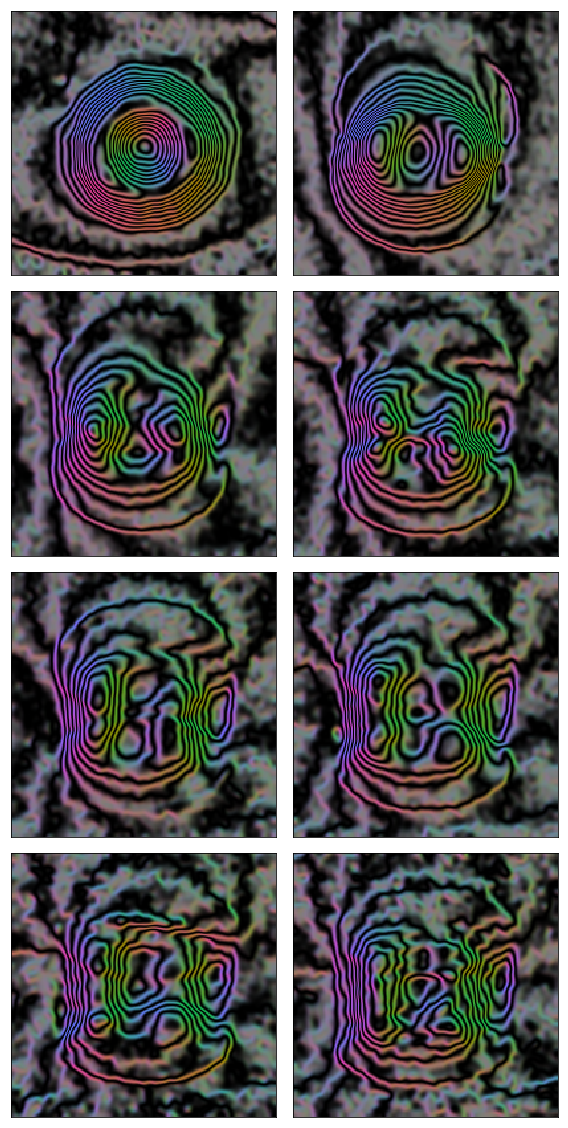

In [2]:
fig2 = plt.figure(figsize=(8,16))
ax2 = {}
for i, angle in enumerate(angles):
    tilt = angle
    phasemaps[i].phase = gaussian_filter(phasemaps[i].phase, sigma=2) 
    
    ax2[i+1] = fig2.add_subplot(4, 2, i+1, aspect='equal')
    ax2[i+1].get_xaxis().set_visible(False)
    ax2[i+1].get_yaxis().set_visible(False)
    phasemaps[i].flip('u').flip('v').plot_holo(axis=ax2[i+1],gain=40,scalebar=False,colorwheel=False,note="")
    plt.tight_layout(h_pad=0.4)